# `biliary_atresia` — End-to-End Tutorial

This notebook walks through the full pipeline in the `biliary_atresia` package, start to finish:

1. Load train / test / pillar data from `.npz` files
2. Run the imaging + segmentation pipeline on a sample image
3. Extract features — **`conv`** method for train augmentation, **`avg`** method for test
4. Train a `RiskMLP` with the combined BCE + pillar-margin loss
5. Persist the model + data as a checkpoint
6. Evaluate on the held-out test set
7. Visualize the learned decision boundary
8. Run single-image inference (the same call path a downstream app would use)
9. Update the model with newly-labeled data (online learning)

> **Note on paths:** all file paths below are placeholders — edit the `CONFIG` cell to point at your
> real data before running for real. A synthetic-data fallback is included so you can run this
> notebook top-to-bottom even without real files, purely to sanity-check the pipeline.


In [30]:
import numpy as np
import matplotlib.pyplot as plt

from biliary_atresia import (
    load_image_rgb, segment_image, extract_lab_feature,
    train_model, predict_probability, predict_binary, predict_three_state,
    save_checkpoint, load_data, update_model, predict_single,
    plot_decision_boundary_and_3d, plot_interactive_3d,
)


## 0. Config — edit these paths

Assumed layout:

- `TRAIN_IMAGES_PATH` — npz with keys `images` (object array of HxWx3 RGB uint8 arrays) and `labels` (0/1)
- `TEST_IMAGES_PATH`  — same schema, held-out set
- `PILLAR_DATA_PATH`  — npz with keys `X_pillar`, `y_pillar` — **already-extracted** LAB feature
  vectors for a small set of trusted/anchor samples (no raw images needed here)
- `CHECKPOINT_DIR` / `MODEL_NAME` — where `save_checkpoint` / `load_model` read and write


In [31]:
TRAIN_IMAGES_PATH = "data/train_images.npz"
TEST_IMAGES_PATH  = "data/test_images.npz"
PILLAR_DATA_PATH  = "data/pillar_data.npz"

CHECKPOINT_DIR = "checkpoints"
MODEL_NAME     = "risk_model_v1"

USE_SYNTHETIC_FALLBACK = True  # flips to False automatically once real files exist


## 1. Load data

If the real `.npz` files aren't present yet, we generate small synthetic ones so the rest of the
notebook is runnable end-to-end. Swap `USE_SYNTHETIC_FALLBACK = False` once you have real data.


In [32]:
import os

def _make_synthetic_image(risky: bool, rng):
    """Fake a stool-sample-like patch: a blob whose LAB darkness/hue depends on `risky`."""
    h, w = 120, 120
    img = np.full((h, w, 3), 200, dtype=np.uint8)  # light background
    cy, cx = h // 2, w // 2
    yy, xx = np.ogrid[:h, :w]
    blob = (yy - cy) ** 2 + (xx - cx) ** 2 <= 40 ** 2
    if risky:
        color = rng.integers(20, 60, size=3)     # dark / reddish-brown
    else:
        color = rng.integers(120, 160, size=3)   # lighter tan
    img[blob] = color
    return img

def _make_synthetic_dataset(n, rng, seed_offset=0):
    images, labels = [], []
    for i in range(n):
        risky = (i + seed_offset) % 2 == 0
        images.append(_make_synthetic_image(risky, rng))
        labels.append(int(risky))
    images_obj = np.empty(len(images), dtype=object)
    for i, im in enumerate(images):
        images_obj[i] = im
    return images_obj, np.array(labels)

if USE_SYNTHETIC_FALLBACK and not (os.path.exists(TRAIN_IMAGES_PATH) and os.path.exists(TEST_IMAGES_PATH) and os.path.exists(PILLAR_DATA_PATH)):
    print("Real data not found — generating synthetic placeholder data for this run.")
    rng = np.random.default_rng(0)

    os.makedirs("data", exist_ok=True)
    train_imgs, train_lbls = _make_synthetic_dataset(24, rng, seed_offset=0)
    test_imgs, test_lbls   = _make_synthetic_dataset(8, rng, seed_offset=1)

    np.savez(TRAIN_IMAGES_PATH, images=train_imgs, labels=train_lbls)
    np.savez(TEST_IMAGES_PATH, images=test_imgs, labels=test_lbls)

    # Pillar / anchor set: a handful of trusted feature vectors + labels (already LAB features)
    X_pillar_syn = rng.normal(loc=[[40, 10, 10]], scale=5, size=(4, 3))
    X_pillar_syn = np.vstack([X_pillar_syn, rng.normal(loc=[[140, -5, 15]], scale=5, size=(4, 3))])
    y_pillar_syn = np.array([1, 1, 1, 1, 0, 0, 0, 0])
    np.savez(PILLAR_DATA_PATH, X_pillar=X_pillar_syn, y_pillar=y_pillar_syn)

train_npz = np.load(TRAIN_IMAGES_PATH, allow_pickle=True)
test_npz  = np.load(TEST_IMAGES_PATH, allow_pickle=True)
pillar_npz = np.load(PILLAR_DATA_PATH, allow_pickle=True)

train_images, train_labels = train_npz["images"], train_npz["labels"]
test_images,  test_labels  = test_npz["images"],  test_npz["labels"]
X_pillar, y_pillar = pillar_npz["X_pillar"], pillar_npz["y_pillar"]

print(f"Train images: {len(train_images)}   Test images: {len(test_images)}   Pillar points: {len(X_pillar)}")


Train images: 16   Test images: 4   Pillar points: 7


## 2. Imaging pipeline — sanity check on one sample

`segment_image` runs Otsu thresholding on the *a*/*b* LAB channels, fills holes, and keeps only the
largest connected component. Always inspect this on a few samples before trusting it in bulk —
see the README / integration report for a known edge case when segmentation finds nothing.


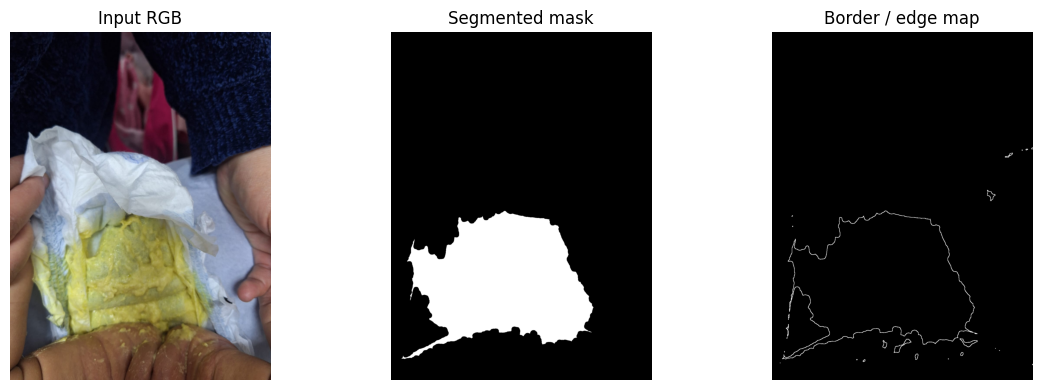

Segmented pixel count: 359707 / 1920000


In [33]:
sample_img = train_images[0]
img_lab, big_mask, border = segment_image(sample_img)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_img); axes[0].set_title("Input RGB"); axes[0].axis("off")
axes[1].imshow(big_mask, cmap="gray"); axes[1].set_title("Segmented mask"); axes[1].axis("off")
axes[2].imshow(border, cmap="gray"); axes[2].set_title("Border / edge map"); axes[2].axis("off")
plt.tight_layout(); plt.show()

print("Segmented pixel count:", int((big_mask > 0).sum()), "/", big_mask.size)


## 3. Feature extraction

- **Train set → `conv` method.** Each image yields several patch-level LAB features instead of one,
  which augments the training set. If an image's segmented region is too small for any patch to pass
  the internal pixel-count filter, `conv` can return zero patches — we fall back to `avg` for that
  image so the loop never silently drops a sample (see the integration report for details on this
  edge case).
- **Test set → `avg` method.** This matches exactly what a deployed app would do for a single image
  via `predict_single`, so test metrics reflect real inference behavior.


In [34]:
X_train_parts, y_train_parts = [], []

for img_rgb, label in zip(train_images, train_labels):
    img_lab, mask, _ = segment_image(img_rgb)
    raw = extract_lab_feature(img_lab, mask, method="conv")
    patch_feats = raw["features"]

    if len(patch_feats) == 0:
        # Defensive fallback: region too small to yield any conv patches.
        patch_feats = extract_lab_feature(img_lab, mask, method="avg")[None, :]

    X_train_parts.append(patch_feats)
    y_train_parts.append(np.full(len(patch_feats), label))

X_syn_train = np.vstack(X_train_parts)
y_syn_train = np.concatenate(y_train_parts)
print(f"Augmented training set: {X_syn_train.shape[0]} samples (from {len(train_images)} images)")


Augmented training set: 949 samples (from 16 images)


In [35]:
X_test, y_test = [], []

for img_rgb, label in zip(test_images, test_labels):
    img_lab, mask, _ = segment_image(img_rgb)
    feat = extract_lab_feature(img_lab, mask, method="avg")
    X_test.append(feat)
    y_test.append(label)

X_test = np.vstack(X_test)
y_test = np.array(y_test)
print(f"Test set: {X_test.shape[0]} samples")


Test set: 4 samples


## 4. Train the model

`X_pillar` / `y_pillar` are the small set of trusted anchor points that get pushed away from the
decision boundary via the margin loss, on top of ordinary BCE on the (now-augmented) synthetic data.


In [36]:
model = train_model(
    X_syn_train, y_syn_train,
    X_pillar, y_pillar,
    hidden_epochs=500,
    lr=1e-3,
    lam=2.0,
    margin=2.0,
    verbose=True,
)


Epoch    0  Loss = 3272.44165
Epoch   50  Loss = 5.20819
Epoch  100  Loss = 2.59918
Epoch  150  Loss = 1.16274
Epoch  200  Loss = 0.71977
Epoch  250  Loss = 0.59692
Epoch  300  Loss = 0.52740
Epoch  350  Loss = 0.49488
Epoch  400  Loss = 0.47673
Epoch  450  Loss = 0.46038


## 5. Save a checkpoint (model weights + the exact data used to train it)

In [37]:
save_checkpoint(
    model, X_syn_train, y_syn_train, X_pillar, y_pillar,
    name=MODEL_NAME, directory=CHECKPOINT_DIR,
    metadata={"feature_method_train": "conv", "feature_method_test": "avg"},
)


Model saved → checkpoints\risk_model_v1.pt
Data saved  → checkpoints\risk_model_v1_data.npz


## 6. Evaluate on the held-out test set

In [38]:
probs = predict_probability(model, X_test)
preds = predict_binary(model, X_test)
three_state = predict_three_state(model, X_test)

accuracy = (preds == y_test).mean()
print(f"Test accuracy: {accuracy:.2%}")

for i in range(len(y_test)):
    print(f"sample {i:2d}  true={y_test[i]}  prob={probs[i]:.3f}  "
          f"binary={preds[i]}  three_state={three_state[i]}")


Test accuracy: 100.00%
sample  0  true=1  prob=0.891  binary=1  three_state=2
sample  1  true=1  prob=0.631  binary=1  three_state=1
sample  2  true=0  prob=0.167  binary=0  three_state=0
sample  3  true=0  prob=0.237  binary=0  three_state=0


## 7. Visualize the decision boundary

These plots assume a 3-D feature vector (LAB), which is what `avg`/`gauss`/`conv`(-averaged)
features all produce.


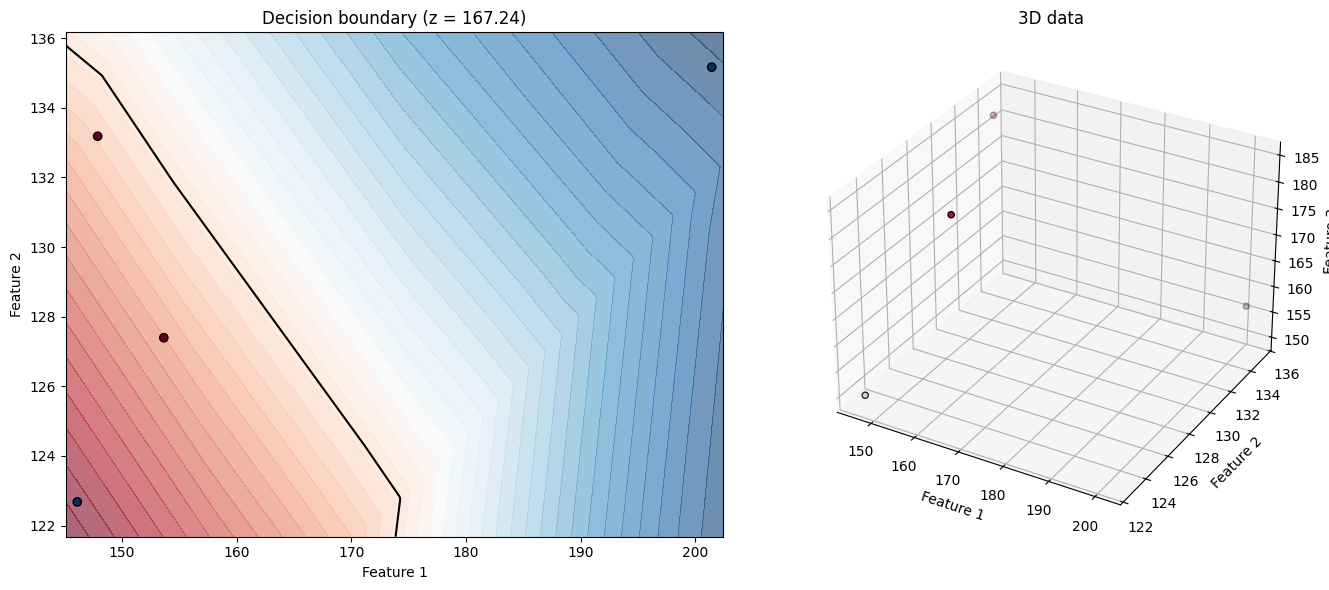

In [39]:
plot_decision_boundary_and_3d(model, X_test, y_test)


In [40]:
# Interactive Plotly view, with pillar/anchor points highlighted
plot_interactive_3d(model, X_test, y_test, X_pillar=X_pillar, y_pillar=y_pillar)


## 8. Single-image inference

This is the exact call path a downstream application (e.g. a mobile app's backend) would use:
one image in, one probability + category out. See the integration report for how to wire this
into a mobile app.


In [41]:
result = predict_single(
    train_images[0],       # could equally be a file path string, or a precomputed feature vector
    feature_method="avg",  # always use "avg" for single-image inference — see integration report
    name=MODEL_NAME,
    directory=CHECKPOINT_DIR,
)

print(result)


{'probability': 0.41623976826667786, 'label': 1, 'label_str': 'unsure', 'feature': array([158.54779028, 119.05632918, 162.49944816])}


## 9. Updating the model with new data

Simulates receiving newly-labeled samples (e.g. from user feedback in the field) and retraining
from the merged dataset. `update_model` loads the existing checkpoint's data, appends the new
rows, retrains from scratch, and atomically overwrites the checkpoint.


In [42]:
new_X_syn = X_test[:2]          # pretend these 2 test points just got confirmed labels
new_y_syn = y_test[:2]

updated_model = update_model(
    new_X_syn=new_X_syn,
    new_y_syn=new_y_syn,
    name=MODEL_NAME,
    directory=CHECKPOINT_DIR,
    train_kwargs={"hidden_epochs": 300, "verbose": False},
)

print("Updated model ready.")


Synthetic data: 949 → 951 samples
Model saved → checkpoints\risk_model_v1.pt
Data saved  → checkpoints\risk_model_v1_data.npz
Updated model ready.


## Wrap-up

- Train-time features came from **`conv`** (many patches per image → richer training signal), with
  a defensive `avg` fallback for tiny regions.
- Test-time / inference-time features came from **`avg`**, matching real single-image inference.
- The checkpoint in `checkpoints/risk_model_v1.pt` (+ `_data.npz`, `_meta.json`) is the artifact a
  backend service would load to serve the mobile app.
- See `README.md` for a file-by-file overview, and the integration report for deployment details,
  including known edge cases to guard against (empty segmentation, `cluster` method not being
  supported by `predict_single`, and NaN features from tiny ROIs with `conv`).
